In [1]:

import os, copy, json, math
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchstain
import timm
import shutil

/home/gandalf/CV_CW/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## CONFIGS

In [2]:

DATA_ROOT          = Path("nuclei_dataset")
TRAIN_DIR          = DATA_ROOT / "train"
VAL_DIR            = DATA_ROOT / "val"
CONTRASTIVE_DIR    = DATA_ROOT / "contrastive_set"

CLASS_NAMES = sorted(["nuclei_histiocyte", "nuclei_lymphocyte", "nuclei_tumor"])
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)
print("Class mapping:", CLASS_TO_IDX)

#PARAMS

EMBED_DIM     = 768       #Depends on Encoder
PROJ_DIM      = 128       # projection head output
TEMPERATURE   = 0.07      # InfoNCE temperature
MOMENTUM      = 0.999     # EMA momentum for key encoder
QUEUE_SIZE    = 8192    

BATCH_SIZE    = 8
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
EPOCHS        = 50
NUM_WORKERS   = 4
ACCUM_STEPS   = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Class mapping: {'nuclei_histiocyte': 0, 'nuclei_lymphocyte': 1, 'nuclei_tumor': 2}
Device: cuda


## MODEL ARCHITECTURE

In [3]:

class ConvNeXtEncoder(nn.Module):
  
    def __init__(self, pretrained: bool = False):
        super().__init__()
        self.backbone = timm.create_model(
            "convnext_small",
            pretrained=pretrained,
            num_classes=0,       
            global_pool="avg" 
        )

    @property
    def out_dim(self) -> int:
        return self.backbone.num_features   # 768

    def forward(self, x):
        return self.backbone(x)


class ProjectionHead(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 2048, out_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class MoCo(nn.Module):
   
    def __init__(
        self,
        embed_dim:  int   = EMBED_DIM,
        proj_dim:   int   = PROJ_DIM,
        queue_size: int   = QUEUE_SIZE,
        momentum:   float = MOMENTUM,
        temperature: float = TEMPERATURE,
    ):
        super().__init__()
        self.queue_size  = queue_size
        self.momentum    = momentum
        self.temperature = temperature
        #Query
        self.encoder_q = ConvNeXtEncoder(pretrained=True)
        self.proj_q    = ProjectionHead(embed_dim, embed_dim, proj_dim)
        # Key 
        self.encoder_k = copy.deepcopy(self.encoder_q)
        self.proj_k    = copy.deepcopy(self.proj_q)
        
    
        for p in list(self.encoder_k.parameters()) + list(self.proj_k.parameters()):
            p.requires_grad = False

        # Queue
        self.register_buffer("queue",  torch.randn(proj_dim, queue_size))
        self.queue = F.normalize(self.queue, dim=0)
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update(self):
        #Key Update
        m = self.momentum
        for p_q, p_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            p_k.data = p_k.data * m + p_q.data * (1.0 - m)
        for p_q, p_k in zip(self.proj_q.parameters(), self.proj_k.parameters()):
            p_k.data = p_k.data * m + p_q.data * (1.0 - m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        batch_size = keys.shape[0]
        ptr = int(self.queue_ptr)

        if ptr + batch_size <= self.queue_size:
            self.queue[:, ptr:ptr + batch_size] = keys.T
        else:
            remaining = self.queue_size - ptr
            self.queue[:, ptr:] = keys[:remaining].T
            overflow = batch_size - remaining
            self.queue[:, :overflow] = keys[remaining:].T

        ptr = (ptr + batch_size) % self.queue_size
        self.queue_ptr[0] = ptr

    def forward(self, x_q, x_k):
       
        # Query projections
        q = self.proj_q(self.encoder_q(x_q))        

        # Key projections 
        with torch.no_grad():
            self._momentum_update()
            k = self.proj_k(self.encoder_k(x_k))    

        # Positive logits
        l_pos = torch.einsum("nc,nc->n", q, k).unsqueeze(-1) / self.temperature

        # Negative logits: query vs entire queue
        l_neg = torch.einsum("nc,ck->nk", q, self.queue.clone().detach()) / self.temperature

        # InfoNCE loss 
        logits = torch.cat([l_pos, l_neg], dim=1)         
        targets = torch.zeros(logits.shape[0], dtype=torch.long, device=logits.device)
        loss = F.cross_entropy(logits, targets)

        # Update the queue
        self._dequeue_and_enqueue(k)

        return loss


## AUGMENTATION

In [4]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

class RandomHEDJitter(object):
    """
    
    """
    def __init__(self, theta=0.05):
        self.theta = theta
        # RGB to HED conversion matrix 
        self.rgb2hed = torch.tensor([
            [0.65, 0.70, 0.29],
            [0.07, 0.99, 0.11],
            [0.27, 0.57, 0.78]
        ], dtype=torch.float32)
        self.hed2rgb = torch.linalg.inv(self.rgb2hed)

    def __call__(self, img):
        import torchvision.transforms.functional as F
        is_pil = False
        if isinstance(img, Image.Image):
            img = F.to_tensor(img)
            is_pil = True
            
        # Add epsilon to prevent log(0) domain errors
        img = torch.clamp(img, 1e-6, 1.0)
        
        # Convert RGB to Optical Density (OD)
        od = -torch.log(img)
        
        # Flatten image to 3 x N
        C, H, W = od.shape
        od_flat = od.view(C, -1)
        
        # Convert OD to HED: HED = hed2rgb * OD
        hed = torch.matmul(self.hed2rgb, od_flat)
        
        # Jitter HED channels independently
        alpha = torch.empty(3, 1).uniform_(1 - self.theta, 1 + self.theta)
        beta = torch.empty(3, 1).uniform_(-self.theta, self.theta)
        
        hed_jittered = hed * alpha + beta
        
        # Convert back to OD: OD = rgb2hed * HED
        od_jittered = torch.matmul(self.rgb2hed, hed_jittered)
        
        # Convert OD back to RGB
        img_jittered = torch.exp(-od_jittered)
        img_jittered = torch.clamp(img_jittered, 0.0, 1.0).view(C, H, W)
        
        if is_pil:
            img_jittered = F.to_pil_image(img_jittered)
            
        return img_jittered


class MoCoTransform:
    """ Transformations for positive samples
    """
    def __init__(self, img_size: int = 96):
        self.transform = T.Compose([
            T.RandomResizedCrop(img_size, scale=(0.6, 1.0)),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.RandomRotation(180),  
            T.RandomApply([RandomHEDJitter(theta=0.05)], p=0.8), 
            T.RandomApply([T.GaussianBlur(kernel_size=7, sigma=(0.1, 2.0))], p=0.5),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __call__(self, img):
       
        return self.transform(img), self.transform(img)


class ValTransform:
    def __init__(self, img_size: int = 96):
        self.transform = T.Compose([
            T.Resize(img_size),
            T.CenterCrop(img_size),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    def __call__(self, img):
        v = self.transform(img)
        return v, v



## DATASET CREATION

In [5]:
class NucleiDataset(Dataset):
  
    def __init__(self, root: str | Path, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.samples = []   
        for class_dir in sorted(self.root.iterdir()):
            if not class_dir.is_dir():
                continue
            class_name = class_dir.name
            if class_name not in CLASS_TO_IDX:
                print(f"Skipping unknown class dir: {class_name}")
                continue
            label = CLASS_TO_IDX[class_name]
            for img_file in sorted(class_dir.glob("*.png")):
                self.samples.append((img_file, label))

        print(f"  {root}: {len(self.samples)} images across "
              f"{len(set(l for _, l in self.samples))} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            view_q, view_k = self.transform(img)
        else:
            view_q = view_k = T.ToTensor()(img)
        return view_q, view_k, label


print("Loading datasets")

train_transform = MoCoTransform(img_size=96)
val_transform   = ValTransform(img_size=96)

train_ds_main = NucleiDataset(TRAIN_DIR, transform=train_transform)
contrastive_ds = NucleiDataset(CONTRASTIVE_DIR, transform=train_transform)
train_ds = ConcatDataset([train_ds_main, contrastive_ds])

val_ds = NucleiDataset(VAL_DIR, transform=val_transform)

print(f"\nTotal training pool:  {len(train_ds)}")
print(f"Validation pool:      {len(val_ds)}")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)


Loading datasets
  nuclei_dataset/train: 7500 images across 3 classes
  nuclei_dataset/contrastive_set: 3000 images across 3 classes
  nuclei_dataset/val: 2100 images across 3 classes

Total training pool:  10500
Validation pool:      2100


## CONTRASTIVE LEARNING PRE-TRAINING

In [6]:

def train_one_epoch(model, loader, optimizer, epoch, device, accumulation_steps=ACCUM_STEPS):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    
    optimizer.zero_grad()

    for i, (view_q, view_k, labels) in enumerate(pbar):
        view_q = view_q.to(device, non_blocking=True)
        view_k = view_k.to(device, non_blocking=True)

        
        loss = model(view_q, view_k)
        loss = loss / accumulation_steps
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()


        current_loss = loss.item() * accumulation_steps
        running_loss += current_loss
        pbar.set_postfix(loss=f"{current_loss:.4f}")

    if len(loader) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()
    torch.cuda.empty_cache()
        
    return running_loss / len(loader)

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    running_loss = 0.0
    pbar = tqdm(loader, desc="[Val]")

    for view_q, view_k, labels in pbar:
        view_q = view_q.to(device, non_blocking=True)
        view_k = view_k.to(device, non_blocking=True)

        loss = model(view_q, view_k)
        running_loss += loss.item()

    torch.cuda.empty_cache() 
    return running_loss / len(loader)


In [7]:
model = MoCo(
    embed_dim=EMBED_DIM,
    proj_dim=PROJ_DIM,
    queue_size=QUEUE_SIZE,
    momentum=MOMENTUM,
    temperature=TEMPERATURE,
).to(DEVICE)


In [ ]:


optimizer = torch.optim.AdamW(
    list(model.encoder_q.parameters()) + list(model.proj_q.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses = []
val_losses   = []
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, epoch, DEVICE, accumulation_steps=ACCUM_STEPS
    )
    val_loss   = validate(model, val_loader, DEVICE)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"LR: {lr_now:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
        }, "best_moco.pth")
        print(f" New best model saved (val_loss={val_loss:.4f})")


print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

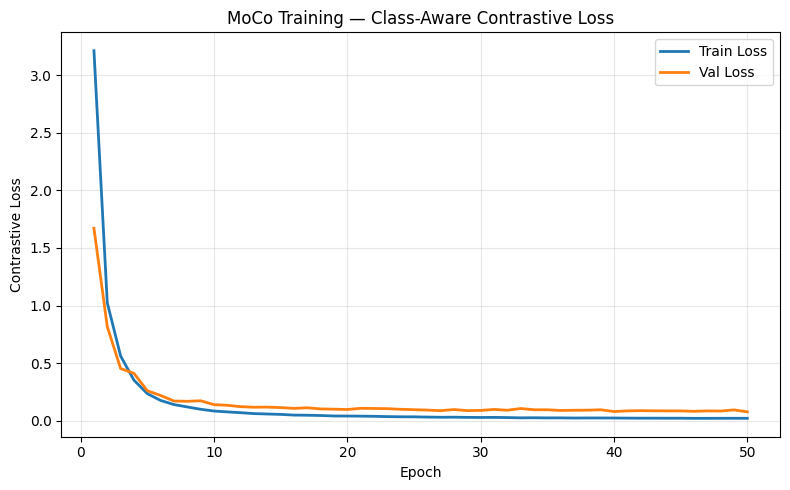

Loss curve saved to moco_loss_curve.png


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss", linewidth=2)
ax.plot(range(1, EPOCHS + 1), val_losses,   label="Val Loss",   linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Contrastive Loss")
ax.set_title("MoCo Training — Class-Aware Contrastive Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("moco_loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved to moco_loss_curve.png")

## CLASSIFIER TRAINING

In [8]:

ckpt = torch.load("best_moco.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print("Loaded MoCo")

class EndToEndMoco(nn.Module):
    def __init__(self, pretrained_encoder, in_dim=1024, num_classes=3, dropout=0.3):
        super().__init__()
        self.encoder = pretrained_encoder
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, num_classes)
        )

    def freeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = False
        print("Encoder frozen.")

    def unfreeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = True
        print("Encoder unfrozen.")

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features)


Loaded MoCo


In [9]:

e2e_model = EndToEndMoco(
    pretrained_encoder=model.encoder_q, 
    in_dim=model.encoder_q.out_dim, 
    num_classes=NUM_CLASSES
).to(DEVICE)

In [10]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)

50145248


In [ ]:
class SupervisedNucleiDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.samples = []   

        for class_dir in sorted(self.root.iterdir()):
            if not class_dir.is_dir(): continue
            class_name = class_dir.name
            if class_name not in CLASS_TO_IDX: continue
            label = CLASS_TO_IDX[class_name]
            for img_file in sorted(class_dir.glob("*.png")):
                self.samples.append((img_file, label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        else: img = T.ToTensor()(img)
        return img, label

class SupervisedTrainTransform(MoCoTransform):
    def __call__(self, img):
        return self.transform(img)

class SupervisedValTransform(ValTransform):
    def __call__(self, img):
        return self.transform(img)

e2e_train_ds = SupervisedNucleiDataset(
    TRAIN_DIR, 
    transform=SupervisedTrainTransform(img_size=96)
)

e2e_val_ds = SupervisedNucleiDataset(
    VAL_DIR, 
    transform=SupervisedValTransform(img_size=96)
)

e2e_train_loader = DataLoader(
    e2e_train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

e2e_val_loader = DataLoader(
    e2e_val_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True
)


In [ ]:
def train_e2e_epoch(model, loader, optimizer, criterion, epoch, epochs, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

    return running_loss / len(loader), correct / total

@torch.no_grad()
def validate_e2e(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="[Val]")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item()

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    torch.cuda.empty_cache()

    return running_loss / len(loader), correct / total


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean', label_smoothing=0.1):
        """
        Focal Loss for Multi-Class Imbalanced Classification.
        alpha: Weight for each class (list or tensor). Deals with imbalance directly.
        gamma: Focusing parameter. High gamma (e.g., 2.0) forces the loss to ignore 'easy' examples and focus purely on 'hard' misclassified ones!
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        
        pt = torch.exp(-ce_loss)
        
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss'
        if self.alpha is not None:
            if isinstance(self.alpha, list):
                self.alpha = torch.tensor(self.alpha, dtype=torch.float32, device=inputs.device)
            
            alpha_t = self.alpha.gather(0, targets)
            focal_loss = focal_loss * alpha_t

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [ ]:
criterion = FocalLoss(alpha=None, gamma=2.0, label_smoothing=0.1)

all_train_losses, all_val_losses = [], []
all_train_accs, all_val_accs = [], []

PROBE_EPOCHS = 5
e2e_model.freeze_encoder()
optimizer = torch.optim.AdamW(e2e_model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

best_probe_acc = 0.0
print(" Starting Linear Probing ")
for epoch in range(PROBE_EPOCHS):
    t_loss, t_acc = train_e2e_epoch(e2e_model, e2e_train_loader, optimizer, criterion, epoch, PROBE_EPOCHS, DEVICE)
    v_loss, v_acc = validate_e2e(e2e_model, e2e_val_loader, criterion, DEVICE)

    all_train_losses.append(t_loss)
    all_val_losses.append(v_loss)
    all_train_accs.append(t_acc)
    all_val_accs.append(v_acc)
    
    print(f"Probe Epoch {epoch+1}/{PROBE_EPOCHS} | Val Acc: {v_acc:.4f}")
    
    if v_acc > best_probe_acc:
        best_probe_acc = v_acc
        torch.save(e2e_model.state_dict(), "best_linear_probe.pth")

print(f"\nLoading best linear probe model (Val Acc: {best_probe_acc:.4f}) before fine-tuning\n")
e2e_model.load_state_dict(torch.load("best_linear_probe.pth", map_location=DEVICE))



FINETUNE_EPOCHS = 10
e2e_model.unfreeze_encoder()

optimizer = torch.optim.AdamW([
    {'params': e2e_model.encoder.parameters(), 'lr': 1e-5},
    {'params': e2e_model.classifier.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)

best_e2e_acc = best_probe_acc

print(" Starting End-to-End Fine-Tuning (Encoder Unfrozen) ")
for epoch in range(FINETUNE_EPOCHS):
    t_loss, t_acc = train_e2e_epoch(e2e_model, e2e_train_loader, optimizer, criterion, epoch, FINETUNE_EPOCHS, DEVICE)
    v_loss, v_acc = validate_e2e(e2e_model, e2e_val_loader, criterion, DEVICE)
    
    all_train_losses.append(t_loss)
    all_val_losses.append(v_loss)
    all_train_accs.append(t_acc)
    all_val_accs.append(v_acc)
    
    print(f"Finetune Epoch {epoch+1}/{FINETUNE_EPOCHS} | Val Acc: {v_acc:.4f}")
    

    if v_acc > best_e2e_acc:
        best_e2e_acc = v_acc
        torch.save(e2e_model.state_dict(), "best_finetuned_moco.pth")
        print(" Saved new best model overall!")
        
    scheduler.step()


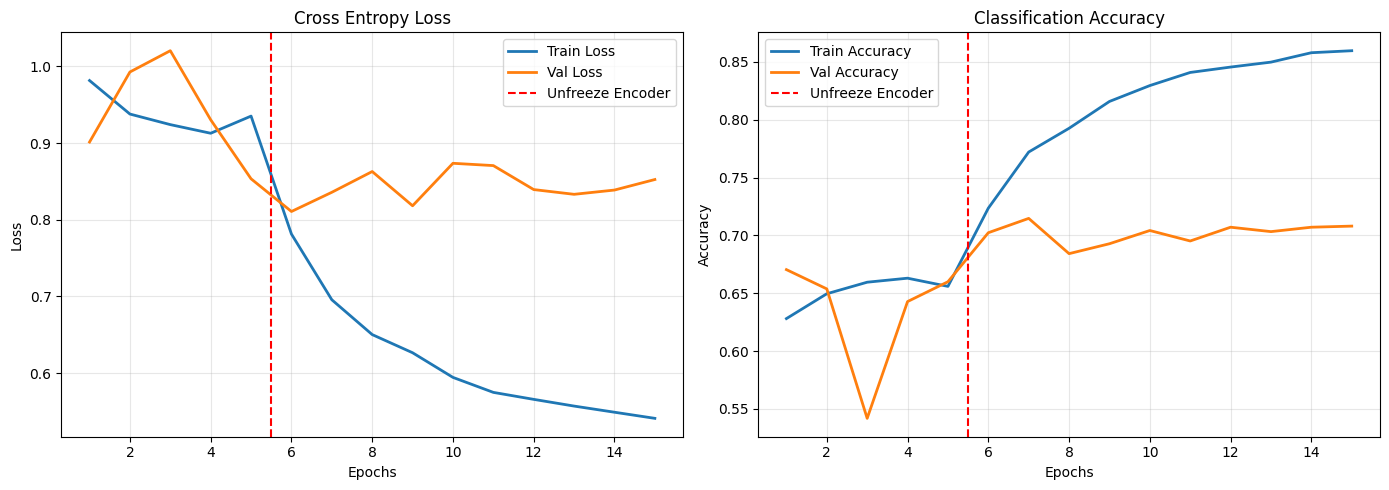

Learning curves saved to e2e_finetune_curves.png


In [ ]:


import matplotlib.pyplot as plt

total_epochs = PROBE_EPOCHS + FINETUNE_EPOCHS
epochs_range = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, all_train_losses, label='Train Loss', linewidth=2)
ax1.plot(epochs_range, all_val_losses, label='Val Loss', linewidth=2)
ax1.axvline(x=PROBE_EPOCHS + 0.5, color='r', linestyle='--', label='Unfreeze Encoder')
ax1.set_title('Cross Entropy Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, all_train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(epochs_range, all_val_accs, label='Val Accuracy', linewidth=2)
ax2.axvline(x=PROBE_EPOCHS + 0.5, color='r', linestyle='--', label='Unfreeze Encoder')
ax2.set_title('Classification Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("e2e_finetune_curves.png", dpi=150)
plt.show()

print("Learning curves saved to e2e_finetune_curves.png")


## EVALUATION

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import re

TEST_DIR = Path("Task2_Test_Set")

def parse_class_from_filename(fname: str) -> str:
   
    m = re.search(r"(nuclei_(?:tumor|lymphocyte|histiocyte))", fname)
    if m:
        return 
    raise ValueError(f"Cannot parse class from: {fname}")

class TestNpyDataset(Dataset):

    def __init__(self, root: Path, transform=None):
        self.transform = transform
        self.samples = []
        for npy_file in sorted(root.glob("*.npy")):
            cls_name = parse_class_from_filename(npy_file.name)
            label = CLASS_TO_IDX[cls_name]
            self.samples.append((npy_file, label))
        print(f"Test set: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        arr = np.load(path)                         
        img = Image.fromarray(arr.astype(np.uint8)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        else:
            img = T.ToTensor()(img)
        return img, label

test_transform = T.Compose([
    T.Resize(96),
    T.CenterCrop(96),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_ds     = TestNpyDataset(TEST_DIR, transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS)

e2e_model.load_state_dict(torch.load("best_finetuned_moco.pth", map_location=DEVICE))
e2e_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test set inference"):
        images = images.to(DEVICE, non_blocking=True)
        
        logits = e2e_model(images)            
        preds  = logits.argmax(dim=1).cpu()
        
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="macro")
rec  = recall_score(all_labels, all_preds, average="macro")
f1   = f1_score(all_labels, all_preds, average="macro")

print(f"\n{'='*50}")
print(f"  Test Set Results ({len(all_labels)} samples)")
print(f"{'='*50}")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}  (macro)")
print(f"  Recall:    {rec:.4f}  (macro)")
print(f"  F1 Score:  {f1:.4f}  (macro)")
print(f"{'='*50}")

print("\n── Per-Class Report ──")
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=4,
))


## PARAMS

In [12]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 100290496
